# Library

Use Case Analysis:
* Profitability analysis by product category and market channel
* Marketing ROAS exploration and campaign-efficiency
* Dashboard building in Power BI

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import re
import os
import gdown as gd
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Data Loading

In [ ]:
!pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download(
    "atharvasoundankar/fmcg-sales-marketing-and-profit-data"
)
print(os.listdir(path))

Using Colab cache for faster access to the 'fmcg-sales-marketing-and-profit-data' dataset.
['fmcg_sales_marketing_profitability_2023_2025.csv']


In [ ]:
df = pd.read_csv(
    path + "/fmcg_sales_marketing_profitability_2023_2025.csv"
)

df.head()

,Order_ID,Order_Date,Year,Quarter,Month,Month_Name,Region,Country,City,Sales_Person,Customer_Type,Sales_Channel,Promotion_Type,Product_Category,Brand,Product_Name,SKU,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
0,FMCG-2025-000001,2025-09-26,2025,Q3,9,September,Oceania,Australia,Perth,Ethan Cole,B2C,Modern Trade,Seasonal Campaign,Personal Care,PureLiva,Shampoo Repair,PCR-PL-101,73,8.47,8.94,618.31,66.05,314.09,43.03,563.03,139.86,24.84
1,FMCG-2024-000002,2024-10-09,2024,Q4,10,October,Asia,India,Mumbai,Meera Nair,B2C,Online,Bundle Offer,Personal Care,BrightSmile,Toothpaste Mint,PCR-BS-301,99,2.89,9.86,286.11,35.26,123.79,23.89,257.90,74.96,29.07
2,FMCG-2024-000003,2024-07-06,2024,Q3,7,July,North America,USA,Los Angeles,Nina Booker,B2B,Distributor,Seasonal Campaign,Personal Care,FreshNest,Body Wash Citrus,PCR-FN-201,361,5.96,15.32,"2,151.56",171.46,"1,011.60",107.02,"1,821.94",531.86,29.19
3,FMCG-2024-000004,2024-05-25,2024,Q2,5,May,Europe,France,Paris,Oliver Kent,B2B,Wholesale,No Promo,Snacks,NutriBite,Protein Bar Peanut,SNK-NB-202,603,3.80,18.00,"2,291.40",118.39,"1,133.66",85.20,"1,878.95",541.70,28.83
4,FMCG-2023-000005,2023-08-10,2023,Q3,8,August,Europe,France,Lyon,Lucas Bennett,B2C,Modern Trade,Loyalty Cashback,Dairy & Breakfast,FarmJoy,Greek Yogurt Plain,DBF-FJ-202,113,3.18,12.46,359.34,34.82,157.70,23.02,314.57,99.03,31.48


# Data Understanding

In [ ]:
df.shape

(18240, 27)

In [ ]:
df.describe()

,Year,Month,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
count,"18,240.00","18,240.00","18,240.00","18,240.00","18,240.00","18,240.00","18,240.00","18,240.00","18,240.00","18,240.00","18,240.00","18,240.00"
mean,"2,024.00",6.52,212.91,4.47,12.94,936.43,85.74,471.02,54.03,792.21,181.41,19.87
std,0.82,3.47,202.10,1.95,5.74,"1,045.61",87.55,537.35,51.27,861.24,239.53,10.57
min,"2,023.00",1.00,5.00,1.45,0.00,13.02,1.81,6.31,1.08,10.54,-637.50,-45.31
25%,"2,023.00",3.00,70.00,3.02,8.71,274.53,33.49,140.51,21.37,245.22,32.34,13.72
50%,"2,024.00",7.00,139.00,3.99,12.69,565.43,61.39,287.16,38.98,493.89,91.89,20.87
75%,"2,025.00",10.00,288.00,5.44,16.85,"1,213.84",107.61,599.79,69.24,"1,027.36",239.12,27.26
max,"2,025.00",12.00,"1,366.00",12.74,28.00,"10,634.12","1,767.71","6,473.33",628.86,"8,752.94","2,723.00",44.49


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18240 entries, 0 to 18239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_ID             18240 non-null  object 
 1   Order_Date           18240 non-null  object 
 2   Year                 18240 non-null  int64  
 3   Quarter              18240 non-null  object 
 4   Month                18240 non-null  int64  
 5   Month_Name           18240 non-null  object 
 6   Region               18240 non-null  object 
 7   Country              18240 non-null  object 
 8   City                 18240 non-null  object 
 9   Sales_Person         18240 non-null  object 
 10  Customer_Type        18240 non-null  object 
 11  Sales_Channel        18240 non-null  object 
 12  Promotion_Type       18240 non-null  object 
 13  Product_Category     18240 non-null  object 
 14  Brand                18240 non-null  object 
 15  Product_Name         18240 non-null 

 ## Missing Values & Duplicate

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Year,0
Quarter,0
Month,0
Month_Name,0
Region,0
Country,0
City,0
Sales_Person,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Data Preparation

## Data Cleaning

> Data Type Correction

In [ ]:
# Ubah data type Order_Date dari object --> datetime

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df.dtypes

,0
Order_ID,object
Order_Date,datetime64[ns]
Year,int64
Quarter,object
Month,int64
Month_Name,object
Region,object
Country,object
City,object
Sales_Person,object


In [ ]:
# validasi apakah ada tanggal yang error/invalid

df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    errors='coerce'
)

print(
    "Invalid date:",
    df['Order_Date'].isna().sum()
)

Invalid date: 0


## Invalid/Negative Values

In [ ]:
negative_revenue = df[df['Net_Revenue_USD'] < 0]
negative_quantity = df[df['Units_Sold'] < 0]
negative_price = df[df['Unit_Price_USD'] < 0]
negative_discount = df[df['Discount_Pct'] < 0]
negative_gross = df[df['Gross_Sales_USD'] < 0]
negative_marketing = df[df['Marketing_Spend_USD'] < 0]
negative_cogs = df[df['COGS_USD'] < 0]
negative_logistics = df[df['Logistics_Cost_USD'] < 0]
negative_profit = df[df['Profit_USD'] < 0]
negative_profit_margin = df[df['Profit_Margin_Pct'] < 0]

print("Negative revenue:", len(negative_revenue))
print("Negative quantity:", len(negative_quantity))
print("Negative price:", len(negative_price))
print("Negative discount:", len(negative_discount))
print("Negative gross:", len(negative_gross))
print("Negative marketing:", len(negative_marketing))
print("Negative COGS:", len(negative_cogs))
print("Negative logistics:", len(negative_logistics))
print("Negative profit:", len(negative_profit))
print("Negative profit margin:", len(negative_profit_margin))

Negative revenue: 0
Negative quantity: 0
Negative price: 0
Negative discount: 0
Negative gross: 0
Negative marketing: 0
Negative COGS: 0
Negative logistics: 0
Negative profit: 784
Negative profit margin: 784


## Outlier Detection

In [ ]:
Q1 = df["Profit_Margin_Pct"].quantile(0.25)
Q3 = df["Profit_Margin_Pct"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Profit_Margin_Pct"] < lower_bound) |
    (df["Profit_Margin_Pct"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 296


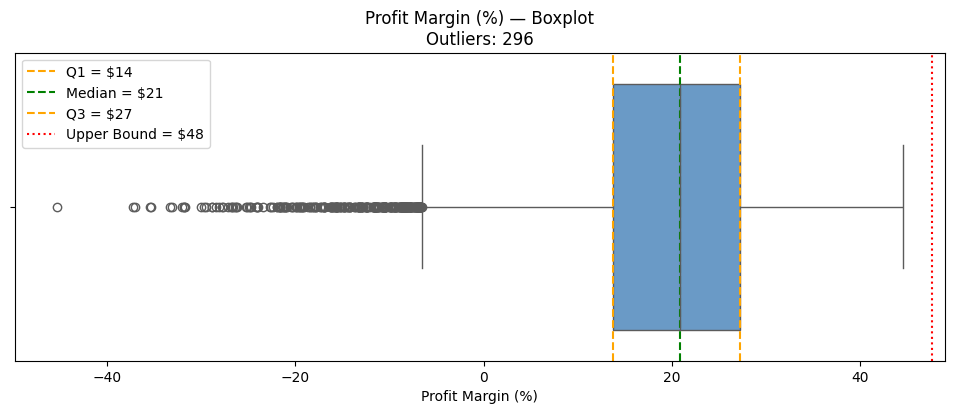

In [ ]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df["Profit_Margin_Pct"],
    color="#5B9BD5"
)

# Q1
plt.axvline(
    Q1,
    color="orange",
    linestyle="--",
    label=f"Q1 = ${Q1:,.0f}"
)

# Median
median = df["Profit_Margin_Pct"].median()

plt.axvline(
    median,
    color="green",
    linestyle="--",
    label=f"Median = ${median:,.0f}"
)

# Q3
plt.axvline(
    Q3,
    color="orange",
    linestyle="--",
    label=f"Q3 = ${Q3:,.0f}"
)

# Upper bound
plt.axvline(
    upper_bound,
    color="red",
    linestyle=":",
    label=f"Upper Bound = ${upper_bound:,.0f}"
)

plt.title(
    f"Profit Margin (%) — Boxplot\n"
    f"Outliers: {len(outliers):,}"
)

plt.xlabel("Profit Margin (%)")
plt.legend()

plt.show()


## Negative Profit Identification

In [ ]:
negative_profit = df[df['Profit_USD'] < 0]

negative_profit[[
    "Order_ID",
    "Customer_Type",
    "Sales_Channel",
    "Product_Category",
    "Units_Sold",
    "Net_Revenue_USD",
    "Profit_USD",
    "Profit_Margin_Pct"
]].sort_values(
    "Profit_USD"
).head()

,Order_ID,Customer_Type,Sales_Channel,Product_Category,Units_Sold,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
8954,FMCG-2023-008955,B2B,Wholesale,Beverages,889,"4,887.54",-637.50,-13.04
14201,FMCG-2023-014202,B2B,Wholesale,Beverages,812,"5,848.86",-489.00,-8.36
9017,FMCG-2023-009018,B2C,Online,Beverages,101,950.03,-336.42,-35.41
15541,FMCG-2025-015542,B2C,Online,Beverages,104,958.81,-307.49,-32.07
15446,FMCG-2024-015447,B2C,Modern Trade,Beverages,203,"1,778.88",-253.55,-14.25


Negative profit detected in several transactions. Now we're gonna analyze the profitability performance, and assess the impact of marketing strategy to the company's profit

# EDA

## 1.Profitability Analysis

###1.1 Product Category

In [ ]:
# profitability by category

category_analysis = (
    df.groupby("Product_Category")
      .agg(
          Orders=("Order_ID", "nunique"),
          Units=("Units_Sold", "sum"),
          Revenue=("Net_Revenue_USD", "sum"),
          Profit=("Profit_USD", "sum"),
          Margin=("Profit_Margin_Pct", "mean")
      )
      .reset_index()
)

category_analysis.sort_values(
    "Profit",
    ascending=False
)

,Product_Category,Orders,Units,Revenue,Profit,Margin
2,Household,3237,683008,"3,160,720.02","832,221.58",22.81
3,Personal Care,3439,686448,"2,765,969.05","776,980.16",25.98
1,Dairy & Breakfast,2925,620692,"2,268,937.27","620,349.83",24.62
4,Snacks,4283,912058,"2,516,605.10","555,212.09",18.37
0,Beverages,4356,981268,"3,737,688.56","524,201.65",11.15


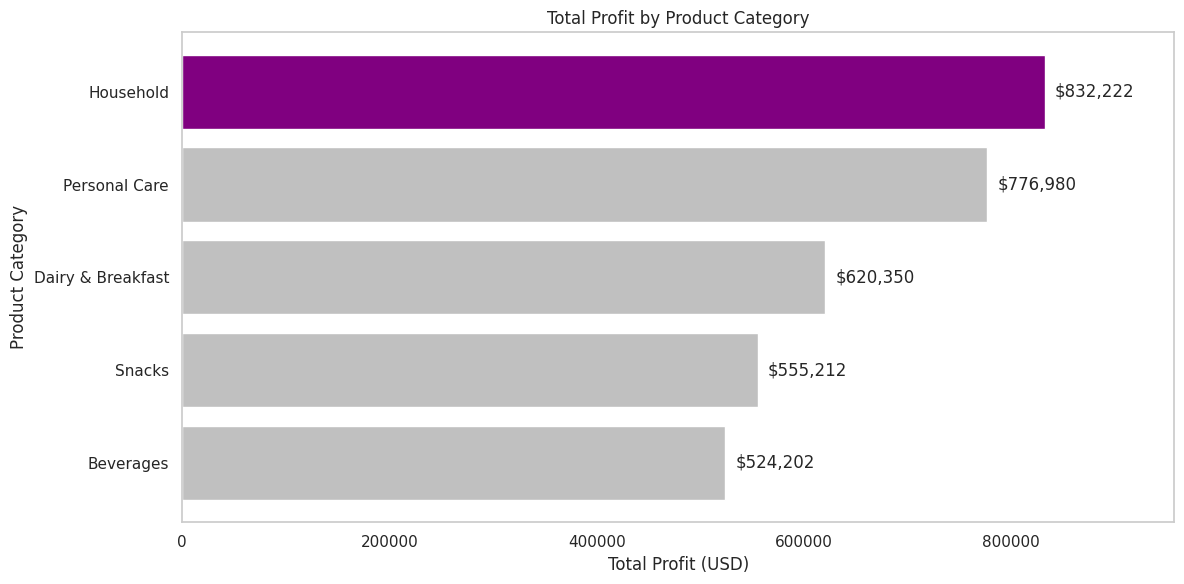

In [ ]:
# Visualization

category_sorted = category_analysis.sort_values(
    "Profit",
    ascending=False
)

# Ambil profit tertinggi
max_profit = category_sorted["Profit"].max()

# Warna
colors = [
    "purple" if profit == max_profit else "silver"
    for profit in category_sorted["Profit"]
]

plt.figure(figsize=(12, 6))

bars = plt.barh(
    category_sorted["Product_Category"],
    category_sorted["Profit"],
    color=colors
)

plt.gca().invert_yaxis()
plt.xlim(0, category_sorted["Profit"].max() * 1.15)

plt.xlabel("Total Profit (USD)")
plt.ylabel("Product Category")
plt.title("Total Profit by Product Category")

# Data labels
for bar in bars:
    plt.text(
        bar.get_width() + 10000,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.0f}",
        va="center"
    )

plt.grid(visible=None)
# plt.savefig("profit_by_category.png", dpi=300)
plt.tight_layout()
plt.show()

Raw finding:

* Household products generate the highest profit.
* On the contrary, Beverages category makes the least, driven by the loss-making transactions it has.

In [ ]:
# Loss generated by categories

loss_by_category = (
    negative_profit.groupby("Product_Category")
    .agg(
        Transactions=("Order_ID", "nunique"),
        Quantity=("Units_Sold", "sum"),
        Revenue=("Net_Revenue_USD", "sum"),
        Loss=("Profit_USD", "sum"),
        Margin=("Profit_Margin_Pct", "mean"),
    )
    .reset_index()
    .sort_values("Loss", ascending=True)
)

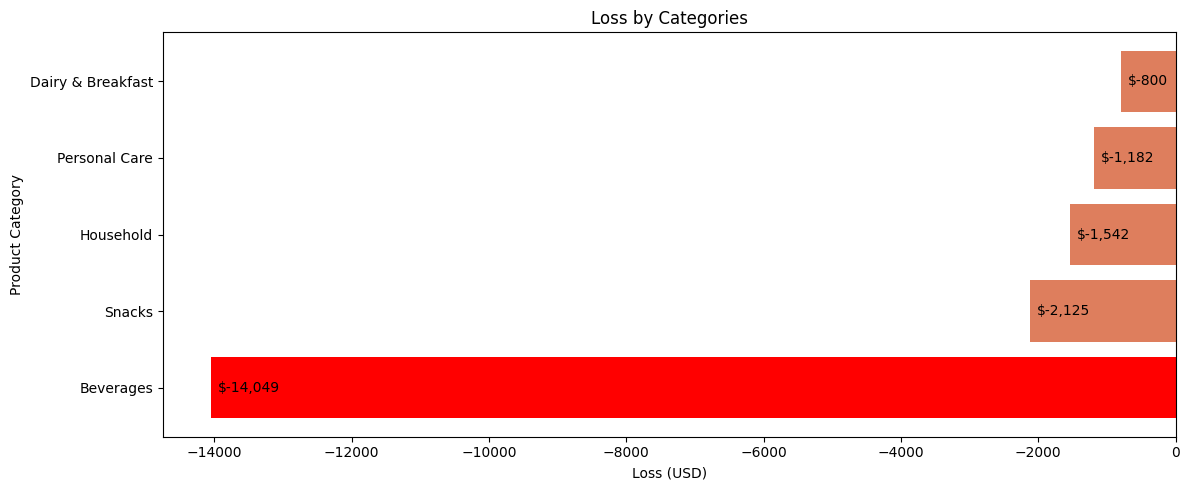

In [ ]:
# Visualization

plot_data = loss_by_category.sort_values(
    "Loss",
    ascending=True
)

# biggest loss
min_loss = plot_data["Loss"].min()

# color
colors = [
    "red" if loss == min_loss else "#de7e5d"
    for loss in plot_data["Loss"]
]

plt.figure(figsize=(12, 5))

bars = plt.barh(
    plot_data["Product_Category"],
    plot_data["Loss"],
    color=colors
)

plt.xlabel('Loss (USD)')
plt.ylabel('Product Category')
plt.title('Loss by Categories')

# labels
for bar in bars:
    plt.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.0f}",
        va="center",
        ha="left",
        fontsize=10
    )


plt.tight_layout()
plt.show()

###1.2 Sales Channel

In [ ]:
# Profitability by Channel

channel_analysis = (
    df.groupby("Sales_Channel")
      .agg(
          Orders=("Order_ID", "nunique"),
          Units=("Units_Sold", "sum"),
          Revenue=("Net_Revenue_USD", "sum"),
          Profit=("Profit_USD", "sum"),
          Margin=("Profit_Margin_Pct", "mean")
      )
      .reset_index()
    )

channel_analysis.sort_values(
    "Profit",
    ascending=False
)

,Sales_Channel,Orders,Units,Revenue,Profit,Margin
3,Wholesale,2848,1456048,"5,208,657.92","1,349,279.25",26.48
0,Distributor,3629,1227016,"4,451,811.56","1,123,393.98",25.46
1,Modern Trade,6219,860610,"3,371,020.34","660,266.21",19.91
2,Online,5544,339800,"1,418,430.18","176,025.87",12.78


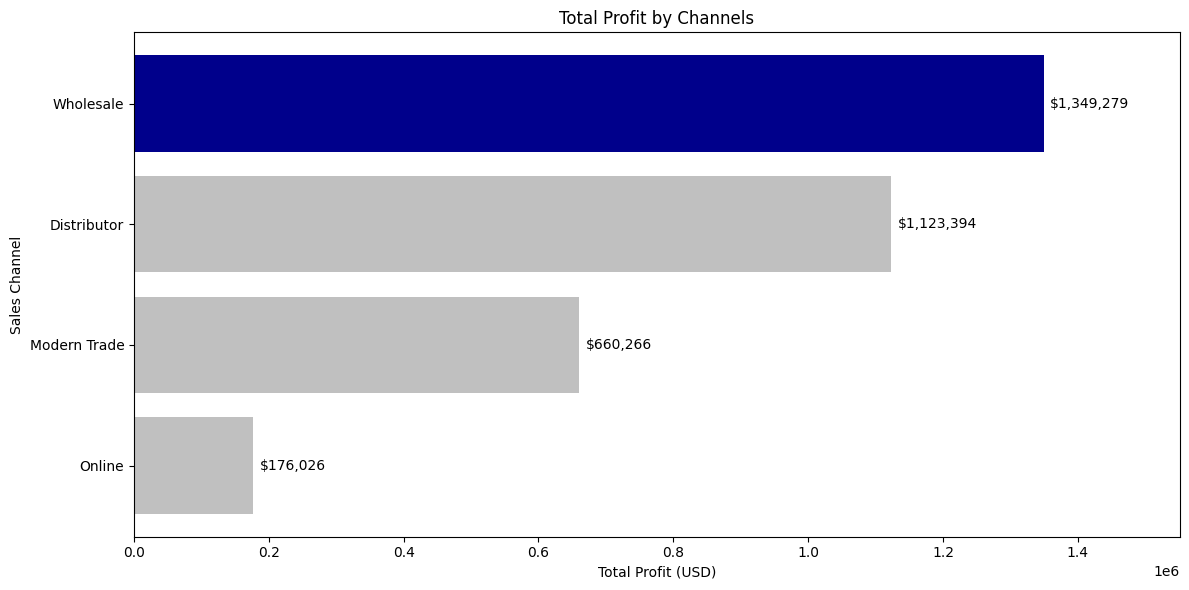

In [ ]:
# Visualization

channel_profit = channel_analysis.sort_values(
    "Profit",
    ascending=False
)

max_profit = channel_profit["Profit"].max()

colors = [
    "darkblue" if profit == max_profit else "silver"
    for profit in channel_profit["Profit"]
]

plt.figure(figsize=(12, 6))

bars = plt.barh(
    channel_profit["Sales_Channel"],
    channel_profit["Profit"],
    color=colors
)

plt.gca().invert_yaxis()
plt.xlim(0, channel_profit["Profit"].max() * 1.15)

plt.xlabel("Total Profit (USD)")
plt.ylabel("Sales Channel")
plt.title("Total Profit by Channels")

# labels
for bar in bars:
    plt.text(
        bar.get_width() + 10000,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Loss generated by channels

loss_by_channel = (
    negative_profit.groupby("Sales_Channel")
    .agg(
        Transactions=("Order_ID", "nunique"),
        Quantity=("Units_Sold", "sum"),
        Revenue=("Net_Revenue_USD", "sum"),
        Loss=("Profit_USD", "sum"),
        Margin=("Profit_Margin_Pct", "mean")
    )
    .reset_index()
    .sort_values("Loss", ascending=True)
)

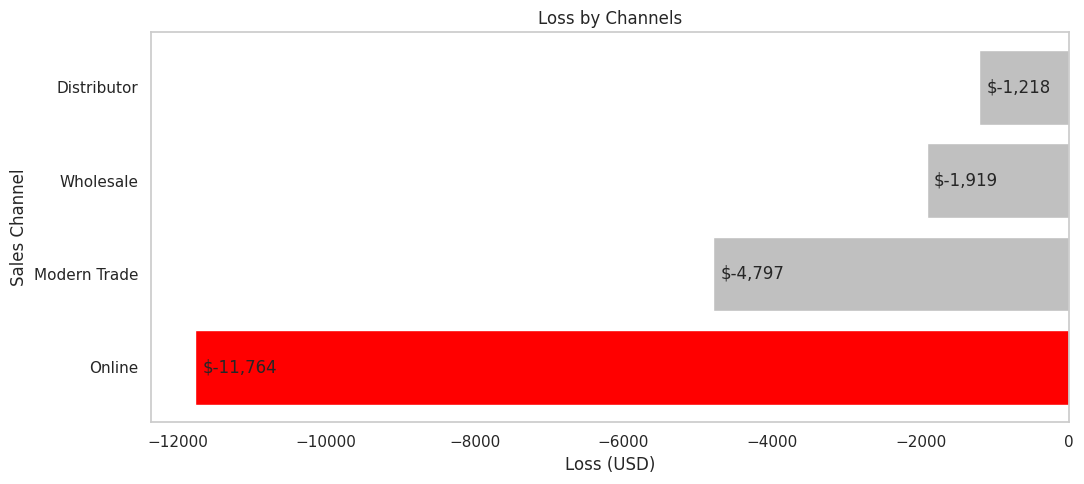

In [ ]:
# Visualization

plot = loss_by_channel.sort_values(
    "Loss",
    ascending=True
)

channel_loss = plot["Loss"].min()

colors = [
    "red" if loss == channel_loss else "silver"
    for loss in plot["Loss"]
]

plt.figure(figsize=(11, 5))

bars = plt.barh(
    plot["Sales_Channel"],
    plot["Loss"],
    color=colors
)

plt.xlabel('Loss (USD)')
plt.ylabel('Sales Channel')
plt.title('Loss by Channels')

# labels
for bar in bars:
    plt.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.0f}",
        va="center"
    )
plt.grid(visible=None)
# plt.savefig("loss_by_channel.png", dpi=300)
plt.tight_layout()
plt.show()

###1.3 Customer Type

In [ ]:
# Profit based on customer type

customer_analysis = (
    df.groupby("Customer_Type")
      .agg(
          Orders=("Order_ID", "nunique"),
          Units=("Units_Sold", "sum"),
          Revenue=("Net_Revenue_USD", "sum"),
          Profit=("Profit_USD", "sum"),
          Margin=("Profit_Margin_Pct", "mean")
      )
      .reset_index()
    )

customer_analysis.sort_values(
    "Profit",
    ascending=False
)

,Customer_Type,Orders,Units,Revenue,Profit,Margin
0,B2B,9163,2990880,"10,912,270.96","2,672,395.38",23.69
1,B2C,9077,892594,"3,537,649.04","636,569.93",16.01


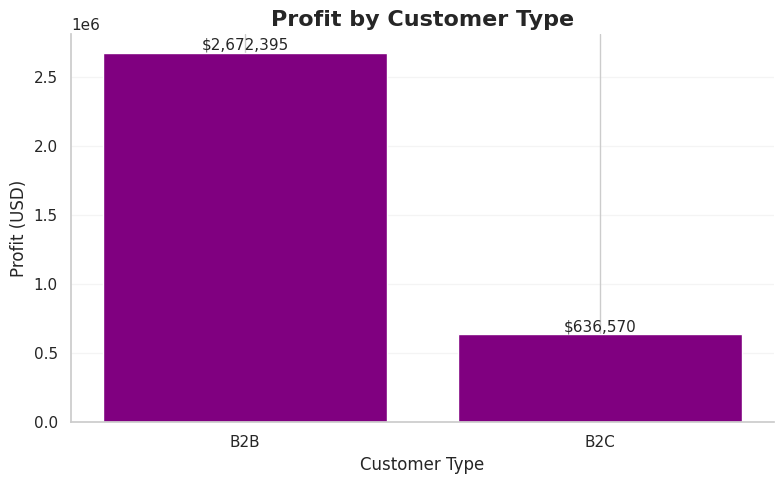

In [ ]:
# Visualization

plt.figure(figsize=(8, 5))

bars = plt.bar(
    customer_analysis['Customer_Type'],
    customer_analysis['Profit'],
    color='purple'
)

plt.title('Profit by Customer Type', fontsize=16, fontweight='bold')
plt.xlabel('Customer Type')
plt.ylabel('Profit (USD)')

# Data labels
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.grid(axis='y', alpha=0.2)
plt.xticks(rotation=0)

# Hilangkan garis atas dan kanan
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

##2.Marketing & Promotion

###2.1 Marketing Spend Efficiency

> Does higher marketing spending correspond with stronger profitability?

In [ ]:
marketing_analysis = (
    df.groupby("Product_Category")
      .agg(
          Marketing_Spend=("Marketing_Spend_USD", "sum"),
          Units=("Units_Sold", "sum"),
          Revenue=("Net_Revenue_USD", "sum"),
          Profit=("Profit_USD", "sum")
      )
      .reset_index()
)

marketing_analysis["ROAS"] = (
    marketing_analysis["Revenue"] /
    marketing_analysis["Marketing_Spend"]
)

marketing_analysis.sort_values(
    "ROAS",
    ascending=False
)

,Product_Category,Marketing_Spend,Units,Revenue,Profit,ROAS
2,Household,"320,530.71",683008,"3,160,720.02","832,221.58",9.86
1,Dairy & Breakfast,"230,501.18",620692,"2,268,937.27","620,349.83",9.84
3,Personal Care,"288,589.92",686448,"2,765,969.05","776,980.16",9.58
0,Beverages,"432,092.21",981268,"3,737,688.56","524,201.65",8.65
4,Snacks,"292,218.01",912058,"2,516,605.10","555,212.09",8.61


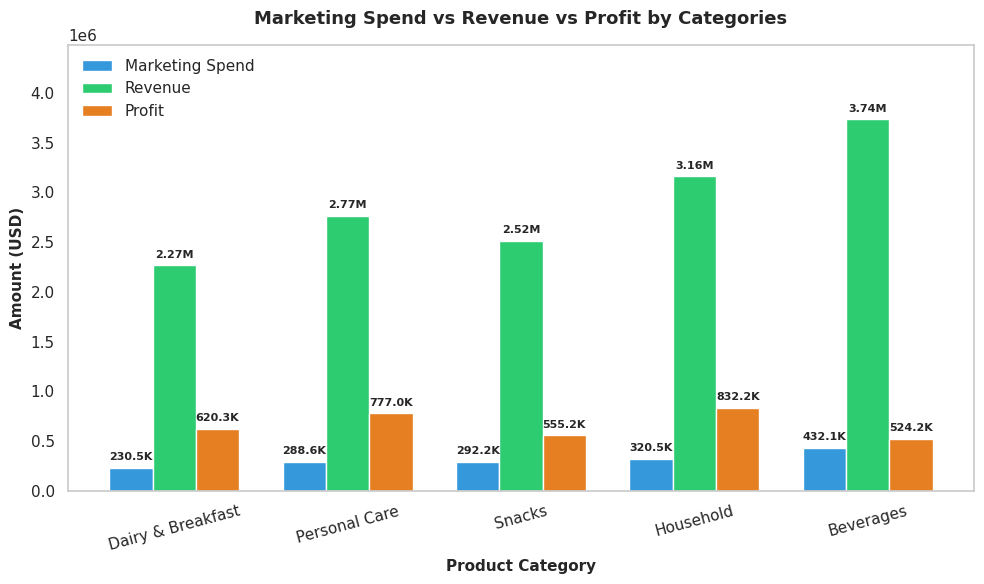

In [ ]:
# Comparative visualization

df_sorted = marketing_analysis.sort_values(
    'Marketing_Spend', ascending=True
).reset_index(drop=True)

categories = df_sorted['Product_Category']
x = np.arange(len(categories))
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(10, 6))

# Creating 3 bars
bar1 = ax.bar(
    x - width,
    df_sorted['Marketing_Spend'],
    width,
    label='Marketing Spend',
    color='#3498db',
)
bar2 = ax.bar(
    x, df_sorted['Revenue'], width, label='Revenue', color='#2ecc71'
)
bar3 = ax.bar(
    x + width, df_sorted['Profit'], width, label='Profit', color='#e67e22'
)

# labeling
def autolabel(bars):
  for bar in bars:
    height = bar.get_height()
    # formating decimals
    if height >= 1_000_000:
      label_text = f'{height/1e6:.2f}M'
    elif height >= 1_000:
      label_text = f'{height/1e3:.1f}K'
    else:
      label_text = f'{height:.1f}'

    ax.annotate(
        label_text,
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=8,
        fontweight='semibold',
    )

# Apply labels to bars
autolabel(bar1)
autolabel(bar2)
autolabel(bar3)

# Setting label, title, and axis
ax.set_xlabel('Product Category', fontweight='bold', fontsize=11)
ax.set_ylabel('Amount (USD)', fontweight='bold', fontsize=11)
ax.set_title(
    'Marketing Spend vs Revenue vs Profit by Categories',
    fontweight='bold',
    fontsize=13,
    pad=15,
)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15)
ax.legend(frameon=True, facecolor='white', edgecolor='none')

ax.set_ylim(0, df_sorted['Revenue'].max() * 1.2)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.grid(visible=None)
plt.savefig("marketing_spend_efficiency.png", dpi=300)
plt.tight_layout()
plt.show()

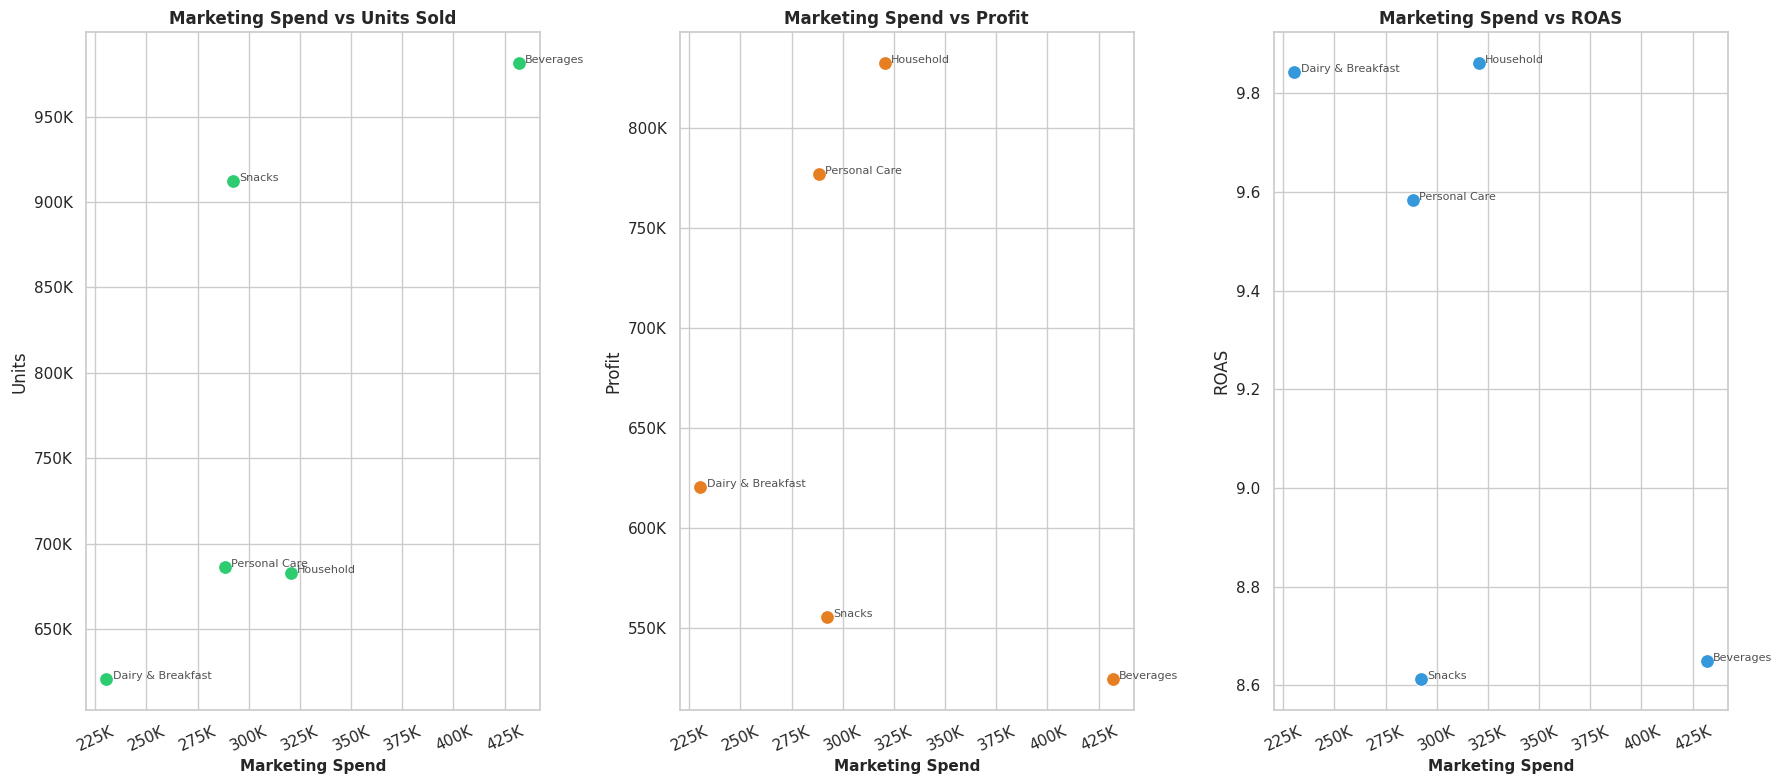

In [ ]:
# Correlative visualization

df_corr = marketing_analysis

# Styling
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Plot 1: Marketing Spend vs Units Sold
sns.scatterplot(
    data=df_corr,
    x='Marketing_Spend',
    y='Units',
    ax=axes[0],
    color='#2ecc71',
    s=100,
)
axes[0].set_title(
    'Marketing Spend vs Units Sold',
    fontsize=12,
    fontweight='bold',
)

axes[0].set_ylabel('Units')
  # Formatting numbers
axes[0].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, pos: f'{y*1e-3:.0f}K')
)

for i, row in df_corr.iterrows():
  axes[0].text(
      row['Marketing_Spend'] + 3000,
      row['Units'],
      row['Product_Category'],
      fontsize=8,
      alpha=0.8,
  )

# Plot 2: Marketing Spend vs Profit
sns.scatterplot(
    data=df_corr,
    x='Marketing_Spend',
    y='Profit',
    ax=axes[1],
    color='#e67e22',
    s=100,
)
axes[1].set_title(
    'Marketing Spend vs Profit',
    fontsize=12,
    fontweight='bold',
)

axes[1].set_ylabel('Profit')
  # Formatting numbers
axes[1].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, pos: f'{y*1e-3:.0f}K')
)

for i, row in df_corr.iterrows():
  axes[1].text(
      row['Marketing_Spend'] + 3000,
      row['Profit'],
      row['Product_Category'],
      fontsize=8,
      alpha=0.8,
  )

# Plot 3: Marketing Spend vs ROAS
sns.scatterplot(
    data=df_corr,
    x='Marketing_Spend',
    y='ROAS',
    ax=axes[2],
    color='#3498db',
    s=100,
)

axes[2].set_title(
    'Marketing Spend vs ROAS',
    fontsize=12,
    fontweight='bold',
)

# Formatting marketing spend numbers
for ax in axes:
  ax.xaxis.set_major_formatter(
      ticker.FuncFormatter(lambda x, pos: f'{x*1e-3:.0f}K')
  )
  ax.tick_params(axis='x', rotation=25)
  ax.set_xlabel('Marketing Spend', fontweight='semibold', fontsize=11)


for i, row in df_corr.iterrows():
  axes[2].text(
      row['Marketing_Spend'] + 3000,
      row['ROAS'],
      row['Product_Category'],
      fontsize=8,
      alpha=0.8,
  )

plt.tight_layout()
plt.show()

Raw finding:
* There is a strong linear correlation between marketing spend and revenue
* However, it shows that marketing spend and profitability are not directly proportional
* Furthermore, the Beverages category indicates diminishing returns and marketing inefficiency as it spends the highest advertising but generates the lowest ROAS and profit, despite having the highest amount of units sold
* Household category shows the most ideal spot for marketing funds optimization.

###2.2 Promotion Effectiveness

> Which promotion produces the best balance of sales and profitability?

In [ ]:
promotion_analysis = (
    df.groupby("Promotion_Type")
      .agg(
          Orders=("Order_ID", "nunique"),
          Units=("Units_Sold", "sum"),
          Revenue=("Net_Revenue_USD", "sum"),
          Profit=("Profit_USD", "sum"),
      )
      .reset_index()
)

promotion_analysis["Margin"] = (
    promotion_analysis["Profit"] /
    promotion_analysis["Revenue"] * 100
)

promotion_analysis["Revenue_per_Order"] = (
    promotion_analysis["Revenue"] /
    promotion_analysis["Orders"]
)

promotion_analysis["Revenue_per_Unit"] = (
    promotion_analysis["Revenue"] /
    promotion_analysis["Units"]
)

promotion_analysis["Profit_per_Order"] = (
    promotion_analysis["Profit"] /
    promotion_analysis["Orders"]
)

promotion_analysis["Profit_per_Unit"] = (
    promotion_analysis["Profit"] /
    promotion_analysis["Units"]
)

promotion_analysis.sort_values(
    "Profit",
    ascending=False
)

,Promotion_Type,Orders,Units,Revenue,Profit,Margin,Revenue_per_Order,Revenue_per_Unit,Profit_per_Order,Profit_per_Unit
5,No Promo,6741,1438634,"5,587,181.47","1,432,411.66",25.64,828.84,3.88,212.49,1.00
0,Bundle Offer,2784,615463,"2,220,908.58","487,231.45",21.94,797.74,3.61,175.01,0.79
6,Seasonal Campaign,2895,602478,"2,216,237.58","477,538.93",21.55,765.54,3.68,164.95,0.79
2,Flash Discount,2140,452027,"1,593,444.48","306,545.88",19.24,744.60,3.53,143.25,0.68
4,Loyalty Cashback,1398,293784,"1,114,225.30","281,314.87",25.25,797.01,3.79,201.23,0.96
1,Festival Campaign,1531,329545,"1,183,731.71","218,696.37",18.48,773.18,3.59,142.85,0.66
3,Introductory Offer,751,151543,"534,190.88","105,226.15",19.70,711.31,3.53,140.11,0.69


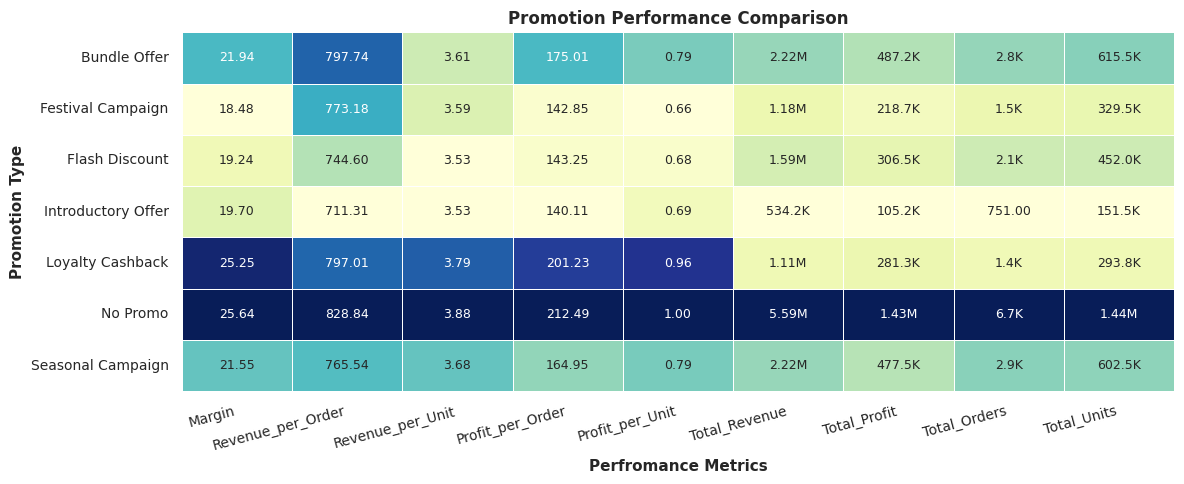

In [ ]:
heatmap_data = promotion_analysis[
    [
        "Promotion_Type",
        "Margin",
        "Revenue_per_Order",
        "Revenue_per_Unit",
        "Profit_per_Order",
        "Profit_per_Unit",
        "Revenue",
        "Profit",
        "Orders",
        "Units"
    ]
].set_index("Promotion_Type")

heatmap_data = heatmap_data.rename(
    columns={"Revenue": 'Total_Revenue', "Profit": "Total_Profit", "Orders": "Total_Orders", "Units": "Total_Units"}
)

annot_data = heatmap_data.copy().astype(str)

for col in heatmap_data.columns:
  for i in heatmap_data.index:
    numbers = heatmap_data.loc[i, col]
    if col in ['Total_Revenue', 'Total_Profit', 'Total_Orders', 'Total_Units']:
      if numbers >= 1_000_000:
        annot_data.loc[i, col] = f'{numbers*1e-6:.2f}M'
      elif numbers >= 1_000:
        annot_data.loc[i, col] = f'{numbers*1e-3:.1f}K'
      else:
        annot_data.loc[i, col] = f'{numbers:.2f}'
    else:
      annot_data.loc[i, col] = f'{numbers:.2f}'

# Normalised with min-max scaling
heatmap_normalized = (
    heatmap_data - heatmap_data.min()
) / (
    heatmap_data.max() - heatmap_data.min()
)
# Creating heatmap
plt.figure(figsize=(12, 5))

ax = sns.heatmap(
    heatmap_normalized,
    annot=annot_data,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.5,
    annot_kws={"fontsize": 9},
    cbar=False
)

plt.title("Promotion Performance Comparison", fontweight='bold', fontsize=12)
plt.xlabel("Perfromance Metrics", fontweight='semibold', fontsize=11)
plt.ylabel("Promotion Type", fontweight='semibold', fontsize=11)
plt.xticks(rotation=15, ha='right', fontweight='medium', fontsize=10)
plt.yticks(fontweight='medium', fontsize=10)

plt.tight_layout()
plt.show()

Raw finding:
> Surprisingly, No Promo shows the best perfomance in generating sales, revenue, and profit

In [ ]:
df.head(1)

,Order_ID,Order_Date,Year,Quarter,Month,Month_Name,Region,Country,City,Sales_Person,Customer_Type,Sales_Channel,Promotion_Type,Product_Category,Brand,Product_Name,SKU,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct,Total_Discount_USD
0,FMCG-2025-000001,2025-09-26,2025,Q3,9,September,Oceania,Australia,Perth,Ethan Cole,B2C,Modern Trade,Seasonal Campaign,Personal Care,PureLiva,Shampoo Repair,PCR-PL-101,73,8.47,8.94,618.31,66.05,314.09,43.03,563.03,139.86,24.84,55.28


In [ ]:
df2 = df.copy()
df2["Discount_Band"] = pd.cut(
    df2["Discount_Pct"],
    bins=[-0.01, 7.5, 15, 22.5, 30],
    labels=[
        "Low Discount",
        "Moderate Discount",
        "High Discount",
        "Very High Discount"
    ]
)

df2["Discount_Band"].value_counts().sort_index()

,count
Discount_Band,
Low Discount,3358
Moderate Discount,8428
High Discount,5405
Very High Discount,1049


In [ ]:
df2["Total_Discount_USD"] = (
    df2["Unit_Price_USD"] *
    (df2["Discount_Pct"] / 100) *
    df2["Units_Sold"]
)

discount_analysis = (
    df2.groupby("Discount_Band", observed=True)
      .agg(
          Orders=("Order_ID", "nunique"),
          Units=("Units_Sold", "sum"),
          Revenue=("Net_Revenue_USD", "sum"),
          Profit=("Profit_USD", "sum"),
          Total_Discount=("Total_Discount_USD", "sum")
      )
      .reset_index()
)

discount_analysis["Discount_per_Order"] = (
    discount_analysis["Total_Discount"] /
    discount_analysis["Orders"]
)

discount_analysis["Profit_per_Order"] = (
    discount_analysis["Profit"] /
    discount_analysis["Orders"]
)

discount_analysis["Profit_Margin"] = (
    discount_analysis["Profit"] /
    discount_analysis["Revenue"] * 100
)

discount_analysis.sort_values(
    "Discount_Band",
    ascending=False
)

,Discount_Band,Orders,Units,Revenue,Profit,Total_Discount,Discount_per_Order,Profit_per_Order,Profit_Margin
3,Very High Discount,1049,431636,"1,404,325.86","323,663.97","465,488.76",443.75,308.55,23.05
2,High Discount,5405,1633632,"5,879,157.29","1,367,480.31","1,315,265.35",243.34,253.00,23.26
1,Moderate Discount,8428,1517674,"5,903,172.21","1,369,951.14","781,128.14",92.68,162.55,23.21
0,Low Discount,3358,300532,"1,263,264.64","247,869.89","68,712.36",20.46,73.81,19.62


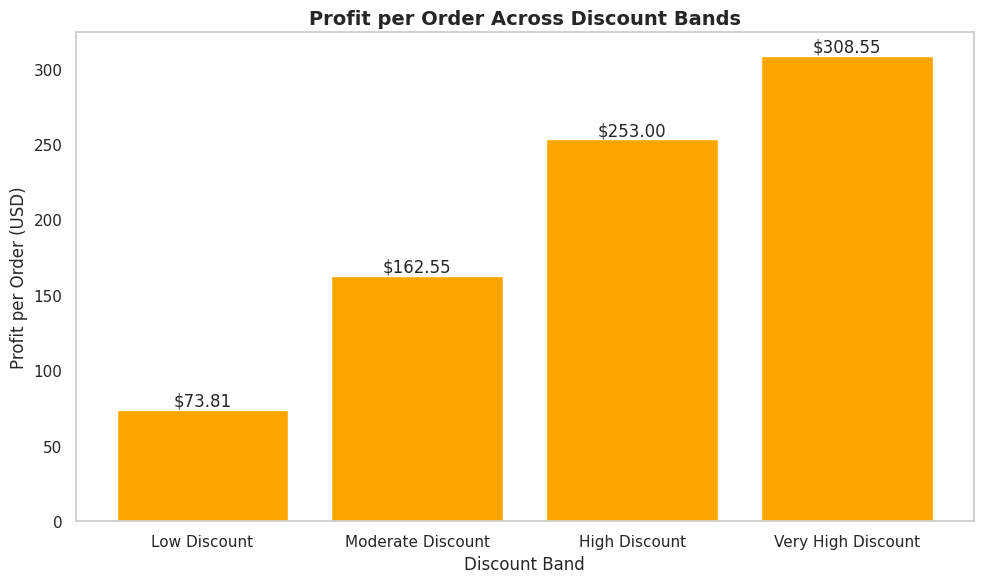

In [ ]:
discount_plot = discount_analysis.sort_values(
    "Discount_Band"
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    discount_plot["Discount_Band"],
    discount_plot["Profit_per_Order"],
    color="orange"
)

plt.title(
    "Profit per Order Across Discount Bands",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Discount Band")
plt.ylabel("Profit per Order (USD)")

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(bars, discount_plot["Profit_per_Order"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${value:,.2f}",
        ha="center",
        va="bottom"
    )

plt.grid(visible=None)
plt.tight_layout()
plt.show()

Finding:
> discounting strategy gives positive impact on profit per order

# Export Data for Power BI

In [ ]:
df_clean = df.copy()
df_clean.head(1)

,Order_ID,Order_Date,Year,Quarter,Month,Month_Name,Region,Country,City,Sales_Person,Customer_Type,Sales_Channel,Promotion_Type,Product_Category,Brand,Product_Name,SKU,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
0,FMCG-2025-000001,2025-09-26,2025,Q3,9,September,Oceania,Australia,Perth,Ethan Cole,B2C,Modern Trade,Seasonal Campaign,Personal Care,PureLiva,Shampoo Repair,PCR-PL-101,73,8.47,8.94,618.31,66.05,314.09,43.03,563.03,139.86,24.84


## Drop column
- drop SKU

In [ ]:
df_clean = df_clean.drop(columns=['SKU'])
df_clean.head(1)

,Order_ID,Order_Date,Year,Quarter,Month,Month_Name,Region,Country,City,Sales_Person,Customer_Type,Sales_Channel,Promotion_Type,Product_Category,Brand,Product_Name,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct
0,FMCG-2025-000001,2025-09-26,2025,Q3,9,September,Oceania,Australia,Perth,Ethan Cole,B2C,Modern Trade,Seasonal Campaign,Personal Care,PureLiva,Shampoo Repair,73,8.47,8.94,618.31,66.05,314.09,43.03,563.03,139.86,24.84


## Add Column

* ROAS


In [ ]:
df_clean["ROAS"] = (
    df["Net_Revenue_USD"] /
    df["Marketing_Spend_USD"]
)
df_clean.head(1)

,Order_ID,Order_Date,Year,Quarter,Month,Month_Name,Region,Country,City,Sales_Person,Customer_Type,Sales_Channel,Promotion_Type,Product_Category,Brand,Product_Name,Units_Sold,Unit_Price_USD,Discount_Pct,Gross_Sales_USD,Marketing_Spend_USD,COGS_USD,Logistics_Cost_USD,Net_Revenue_USD,Profit_USD,Profit_Margin_Pct,ROAS
0,FMCG-2025-000001,2025-09-26,2025,Q3,9,September,Oceania,Australia,Perth,Ethan Cole,B2C,Modern Trade,Seasonal Campaign,Personal Care,PureLiva,Shampoo Repair,73,8.47,8.94,618.31,66.05,314.09,43.03,563.03,139.86,24.84,8.52


## Export (CSV)


In [ ]:
# df_clean.to_csv("fmcg_clean.csv", index=False)
#df_clean.to_excel("FMCG_clean.xlsx", index=False)